# SCC0276 - Aprendizado de Máquina - EXERCÍCIO 3


---

## Objetivo

O objetivo principal desta atividade é encontrar o modelo que melhor classifica o conjunto de dados **Heart Disease (Cleveland)**, avaliando diferentes algoritmos e utilizando métricas de desempenho robustas.

Os métodos a serem estudados são:
* **MLP:** Multilayer Perceptron
* **DT:** Decision Tree
* **RF:** Random Forest


# Dataset: Heart Disease (Cleveland)

## Visão Geral

| Atributo | Descrição |
|---|---|
| **Origem** | UCI Machine Learning Repository |
| **Acesso em** | https://archive.ics.uci.edu/dataset/45/heart+disease |
| **Doado em** | 30/06/1988 |
| **Bases disponíveis** | Cleveland, Hungria, Suíça, VA Long Beach |
| **Base mais utilizada** | Cleveland |
| **Instâncias** | 303 |
| **Features** | 13 (subconjunto de 76 atributos originais) |
| **Tarefa** | Classificação |
| **Valores ausentes** | Sim |

## Descrição

O dataset reúne registros clínicos de pacientes com o objetivo de diagnosticar a presença de doença cardíaca. Originalmente composto por 76 atributos, a literatura consolidou o uso de apenas **14 variáveis** (13 features + 1 alvo), todas provenientes da base de Cleveland — a única amplamente adotada em experimentos de aprendizado de máquina.

## Variável Alvo

A variável `num` indica o **diagnóstico de doença cardíaca**, com valores de 0 a 4:

- `0` → ausência de doença
- `1–4` → presença de doença (graus crescentes)

> Na prática, a maioria dos experimentos simplifica o problema para **classificação binária**: ausência (`0`) vs. presença (`1, 2, 3 ou 4`).

## Features

| # | Variável | Tipo | Descrição | Unidade | Missing |
|---|---|---|---|---|---|
| 1 | `age` | Inteiro | Idade do paciente | anos | Não |
| 2 | `sex` | Categórico | Sexo | — | Não |
| 3 | `cp` | Categórico | Tipo de dor no peito | — | Não |
| 4 | `trestbps` | Inteiro | Pressão arterial em repouso (na admissão) | mm Hg | Não |
| 5 | `chol` | Inteiro | Colesterol sérico | mg/dl | Não |
| 6 | `fbs` | Categórico | Glicemia em jejum > 120 mg/dl | — | Não |
| 7 | `restecg` | Categórico | Resultado do eletrocardiograma em repouso | — | Não |
| 8 | `thalach` | Inteiro | Frequência cardíaca máxima atingida | bpm | Não |
| 9 | `exang` | Categórico | Angina induzida por exercício | — | Não |
| 10 | `oldpeak` | Real | Depressão do segmento ST induzida por exercício | — | Não |
| 11 | `slope` | Categórico | Inclinação do segmento ST no pico do exercício | — | Não |
| 12 | `ca` | Inteiro | Nº de vasos principais coloridos por fluoroscopia (0–3) | — | **Sim** |
| 13 | `thal` | Categórico | Resultado do teste de talassemia | — | **Sim** |

## Valores Ausentes

Apenas duas variáveis apresentam dados faltantes: **`ca`** e **`thal`**. Ambas são clinicamente relevantes, o que torna necessário um tratamento cuidadoso antes da modelagem (imputação ou remoção de instâncias).

## Referência

> Detrano, R. et al. *International application of a new probability algorithm for the diagnosis of coronary artery disease.* **American Journal of Cardiology**, 1989.

# 0) Preparo dos dados

Os códigos a seguir focam no preparo dos dados para a avaliação dos dois métodos mencionados.

## Carregando o dataset a partir do arquivo fornecido e contando quantos valores ausentes existem para cada atributo.

In [ ]:
# Instala a biblioteca oficial do UCI ML Repository para acesso aos datasets

!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# Baixa o dataset Heart Disease diretamente do UCI pelo seu ID (45)
heart_disease = fetch_ucirepo(id=45)

# Separa os dados em features (variáveis de entrada) e target (variável alvo)
X = heart_disease.data.features
y = heart_disease.data.targets

In [ ]:
# Exibe as primeiras linhas do dataframe de features
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0


In [ ]:
# Exibe informações gerais do dataframe: tipos de dados, contagem de valores não-nulos e uso de memória
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


In [ ]:
# Conta os valores ausentes (NaN) por coluna — útil para identificar onde estão os dados faltantes
X.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# Exibe as primeiras linhas do dataframe de target
y

,num
0,0
1,2
2,1
3,0
4,0
...,...
298,1
299,2
300,3
301,1


In [ ]:
# Converte y de DataFrame para array 1D (necessário para evitar warnings no sklearn)
y = y.values.ravel()
y

array([0, 2, 1, 0, 0, 0, 3, 0, 2, 1, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 3, 4, 0, 0, 0, 0, 3, 0, 2, 1, 0, 0, 0, 3, 1, 3, 0, 4, 0, 0, 0,
       1, 4, 0, 4, 0, 0, 0, 0, 2, 0, 1, 1, 1, 1, 0, 0, 2, 0, 1, 0, 2, 2,
       1, 0, 2, 1, 0, 3, 1, 1, 1, 0, 1, 0, 0, 3, 0, 0, 0, 3, 0, 0, 0, 0,
       0, 0, 0, 3, 0, 0, 0, 1, 2, 3, 0, 0, 0, 0, 0, 0, 3, 0, 2, 1, 2, 3,
       1, 1, 0, 2, 2, 0, 0, 0, 3, 2, 3, 4, 0, 3, 1, 0, 3, 3, 0, 0, 0, 0,
       0, 0, 0, 0, 4, 3, 1, 0, 0, 1, 0, 1, 0, 1, 4, 0, 0, 0, 0, 0, 0, 4,
       3, 1, 1, 1, 2, 0, 0, 4, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 1, 0, 4, 1,
       0, 1, 0, 0, 3, 2, 0, 0, 1, 0, 0, 2, 1, 2, 0, 3, 1, 2, 0, 3, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 3, 3, 3, 0, 1, 0, 4, 0, 3, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 3, 1, 0, 0, 0, 3, 2, 0, 2, 1, 0, 0, 3, 2, 1, 0, 0, 0, 0,
       0, 2, 0, 2, 2, 1, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 0,
       4, 2, 2, 2, 1, 0, 1, 0, 2, 0, 1, 0, 0, 0, 1, 0, 2, 0, 3, 0, 2, 4,
       2, 0, 0, 0, 1, 0, 2, 2, 1, 0, 3, 1, 1, 2, 3,

In [ ]:
# Binariza o alvo: 0 → sem doença, 1 → com doença (valores 1,2,3,4 viram 1)
y = (y != 0).astype(int)
y

array([0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,

## Separando o conjunto em $80\%$ treino e $20\%$ teste.

Preparação de um conjunto de avaliação utilizando **holdout**, separando 20% dos dados para teste.

In [ ]:
from sklearn.model_selection import train_test_split

# Divide os dados em treino (80%) e teste (20%), com semente fixa para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2026)

##

## Imputar valores ausentes

In [ ]:
from sklearn.impute import SimpleImputer

# Instancia o imputador com estratégia de média
imputer = SimpleImputer(strategy='mean')

# Aprende a média de cada coluna no treino e já transforma
X_train = imputer.fit_transform(X_train)

# Aplica as médias aprendidas no treino ao conjunto de teste (sem recalcular)
X_test = imputer.transform(X_test)

In [ ]:
import pandas as pd

print("Valores ausentes - Treino:\n", pd.DataFrame(X_train).isnull().sum().values)
print("Valores ausentes - Teste:\n",  pd.DataFrame(X_test).isnull().sum().values)

Valores ausentes - Treino:
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
Valores ausentes - Teste:
 [0 0 0 0 0 0 0 0 0 0 0 0 0]


# Métricas de Avaliação de Modelos de Classificação

Antes de entender as métricas, é útil conhecer os quatro blocos fundamentais que saem da **Matriz de Confusão**:

| | Previsto Positivo | Previsto Negativo |
|---|---|---|
| **Real Positivo** | VP (Verdadeiro Positivo) | FN (Falso Negativo) |
| **Real Negativo** | FP (Falso Positivo) | VN (Verdadeiro Negativo) |

---

## 🔲 Matriz de Confusão

A matriz de confusão resume **todos os erros e acertos** do modelo de forma tabular. Cada célula indica quantas instâncias foram classificadas em cada combinação de classe real vs. classe prevista.

> **Intuição:** é o "raio-x" do modelo — permite ver não só *quantos* erros ocorreram, mas *que tipo* de erro.

---

## ✅ Acurácia (*Accuracy*)

Proporção de previsões corretas sobre o total de instâncias.

$$\text{Acurácia} = \frac{VP + VN}{VP + VN + FP + FN}$$

> **Intuição:** "de tudo que o modelo classificou, quanto ele acertou?" — simples, mas pode ser enganosa em datasets desbalanceados.

---

## 🎯 Precisão (*Precision*)

Dos exemplos que o modelo disse ser positivos, quantos realmente são?

$$\text{Precisão} = \frac{VP}{VP + FP}$$

> **Intuição:** mede a **confiabilidade dos alarmes** — um modelo com alta precisão raramente dá falsos alarmes.

---

## 🔍 Revocação (*Recall*)

Dos exemplos que realmente são positivos, quantos o modelo encontrou?

$$\text{Revocação} = \frac{VP}{VP + FN}$$

> **Intuição:** mede a **capacidade de encontrar todos os positivos** — importante quando deixar passar um caso positivo tem alto custo (ex: diagnóstico de câncer).

---

## 📈 Taxa de Verdadeiros Positivos (TVP)

A TVP é **equivalente à Revocação** (também chamada de *Sensibilidade*):

$$\text{TVP} = \frac{VP}{VP + FN}$$

> **Intuição:** "dos doentes, quantos o modelo identificou como doentes?" — eixo Y da curva ROC.

---

## 📉 Taxa de Falsos Positivos (TFP)

Dos exemplos que realmente são negativos, quantos o modelo classificou erroneamente como positivos?

$$\text{TFP} = \frac{FP}{FP + VN}$$

> **Intuição:** "dos saudáveis, quantos o modelo acusou erroneamente?" — eixo X da curva ROC.

---

## 📊 Curva ROC (*Receiver Operating Characteristic*)

A curva ROC plota a **TVP (eixo Y) contra a TFP (eixo X)** para todos os limiares de decisão possíveis do modelo.

$$\text{AUC} = \int_0^1 \text{TVP}(\text{TFP})\, d(\text{TFP})$$

Onde **AUC** (*Area Under the Curve*) resume a curva em um único número:

| AUC | Interpretação |
|-----|--------------|
| 1.0 | Modelo perfeito |
| 0.5 | Equivalente a chute aleatório |
| < 0.5 | Modelo pior que aleatório |

> **Intuição:** quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo distingue as classes — independente do limiar escolhido.



In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
import numpy as np

def evaluate_classifier(y_test, y_pred, y_prob=None, model_name="Modelo"):

    print(f"-------- {model_name} --------\n")

    # Métricas básicas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)

    print("Acurácia: %.4f" % acc)
    print("Precisão: %.4f" % prec)
    print("Sensibilidade (Taxa de Verdadeiros Positivos - TVP): %.4f" % rec)

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    tvp = tp / (tp + fn)
    tfp = fp / (fp + tn)

    print("Taxa de Verdadeiros Positivos (TVP): %.4f" % tvp)
    print("Taxa de Falsos Positivos (TFP): %.4f" % tfp)

    # ----- Plot Matriz de Confusão -----
    plt.figure()
    plt.imshow(cm)
    plt.title(f"Matriz de Confusão - {model_name}")
    plt.colorbar()

    classes = ["Benigno", "Maligno"]
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     horizontalalignment="center")

    plt.ylabel("Classe Real")
    plt.xlabel("Classe Predita")
    plt.show()

    # ----- Curva ROC -----
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr)
        plt.plot([0, 1], [0, 1])
        plt.xlabel("Taxa de Falsos Positivos (TFP)")
        plt.ylabel("Taxa de Verdadeiros Positivos (TVP)")
        plt.title(f"Curva ROC - {model_name}")
        plt.show()

        print("Área sob a Curva (AUC): %.4f" % roc_auc)
    else:
        roc_auc = None
        print("Curva ROC não calculada (probabilidades não fornecidas).")

# 1) Multi-Layer Perceptron

Para começar o exercício, avalie um modelo Multi-Layer Perceptron ([MLP](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)).

- a) Revise a documentação do MLP, e crie um modelo com parâmetros customizados (ex: customize o número de camadas e neurônios). Use o número 2026 como seed.
- b) Normalize os dados de treino e teste usando o [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html). O objetivo deste pré-processamento é forçar que os dados numéricos tenham valores entre 0 e 1.
- c) Treine o modelo e extraia suas métricas usando a função "*evaluate_classifier*" definida anteriormente.





-------- MLP --------

Acurácia: 0.9180
Precisão: 1.0000
Sensibilidade (Taxa de Verdadeiros Positivos - TVP): 0.8571
Taxa de Verdadeiros Positivos (TVP): 0.8571
Taxa de Falsos Positivos (TFP): 0.0000


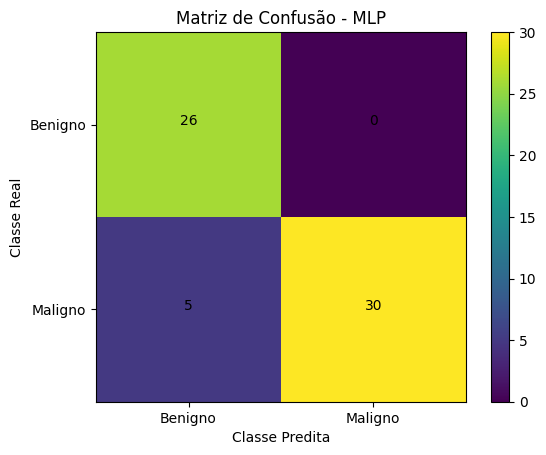

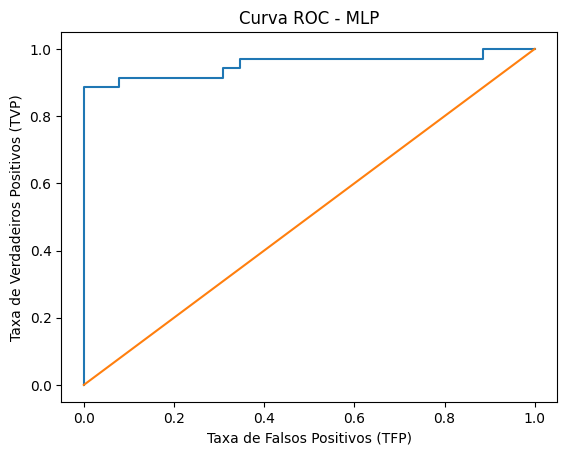

Área sob a Curva (AUC): 0.9538


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
# Instanciando scaler
scaler = MinMaxScaler()
# Aprendendo a escala e aplicando
X_train_scaled = scaler.fit_transform(X_train)
# Aplicando escala
X_test_scaled = scaler.transform(X_test)
# Instanciando modelo
mlp = MLPClassifier(hidden_layer_sizes=(10, 10), random_state=2026, max_iter=2000)
# Treinando modelo e ralizando previsões
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)
# Calculando probabilidade prevista, e pegando apenas os positivos, pois a ROC foi concebida para um cenário binário e convencionalmente se usa as probabilidades da classe positiva
y_prob = mlp.predict_proba(X_test_scaled)[:,1]
# Métricas
evaluate_classifier(y_test, y_pred, y_prob, model_name="MLP")

## 2) Árvores de Decisão e sua avalição

Os itens a seguir visam explorar o funcionamento do modelo de Árvore de Decisão e interpretar sua estrutura, e seguem uma estrutura similar ao exercício da última semana.

- a) Crie uma [árvore de decisão](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) usando seus parâmetros padrão.  
- b) Avalie o modelo utilizando a função "*evaluate_classifier*" novamente. Para este modelo, utilize o "*X_train*" e "*X_test*" **sem pré-processamento**.
- c) Tendo treinado o modelo (chamado a função "*fit*"), visualize a Arvore de Decisão resultante utilizando a função ["*plot_tree*"](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html). Para melhorar a visualização, atente-se ao parâmetro "*max_depth*", se necessário.
- d) Repita avaliação, considerando dois modelos. Um configurando o parâmetro "*max_depth*" igual a *None* e outro configurando o parâmetro igual a 2. Aponte e discuta a melhor configuração.


-------- DecisionTree --------

Acurácia: 0.7377
Precisão: 0.7879
Sensibilidade (Taxa de Verdadeiros Positivos - TVP): 0.7429
Taxa de Verdadeiros Positivos (TVP): 0.7429
Taxa de Falsos Positivos (TFP): 0.2692


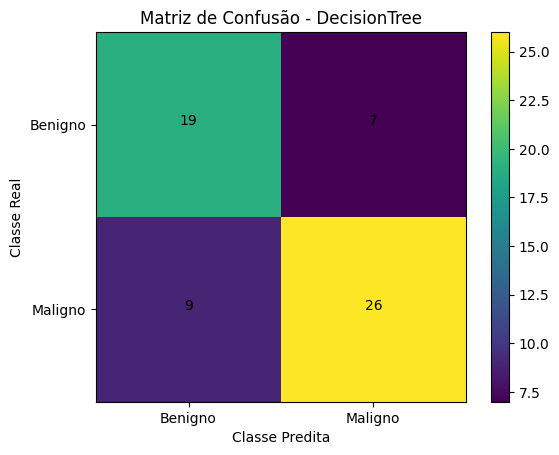

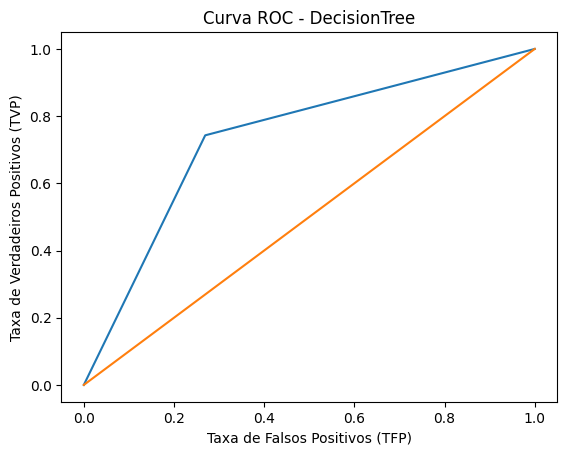

Área sob a Curva (AUC): 0.7368


[Text(0.5, 0.875, 'x[12] <= 3.863\ngini = 0.49\nsamples = 242\nvalue = [138, 104]'),
 Text(0.25, 0.625, 'x[11] <= 0.819\ngini = 0.313\nsamples = 134\nvalue = [108, 26]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[7] <= 161.5\ngini = 0.185\nsamples = 97\nvalue = [87, 10]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'x[2] <= 3.5\ngini = 0.491\nsamples = 37\nvalue = [21, 16]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'x[2] <= 3.5\ngini = 0.401\nsamples = 108\nvalue = [30, 78]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[7] <= 143.0\ngini = 0.494\nsamples = 36\nvalue = [20, 16]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'x[9] <= 0.55\ngini = 0.239\nsamples = 72\nvalue = [10, 62]'),
 Text(0.8125, 0.125, '\n  (...)  \n'),
 Text(0.9375, 0.125, '\n  (...)  \n')]

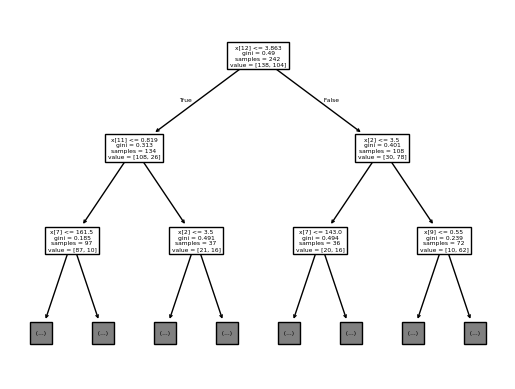

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
# Instanciando modelo sem definir max_depth
dt = DecisionTreeClassifier()
# Treinando e realizando previsões
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:,1]
# Avaliando o modelo
evaluate_classifier(y_test, y_pred, y_prob, model_name="DecisionTree")
# Plotando árvore
plot_tree(dt, max_depth=2)

-------- DecisionTreeMaxDepth --------

Acurácia: 0.7377
Precisão: 1.0000
Sensibilidade (Taxa de Verdadeiros Positivos - TVP): 0.5429
Taxa de Verdadeiros Positivos (TVP): 0.5429
Taxa de Falsos Positivos (TFP): 0.0000


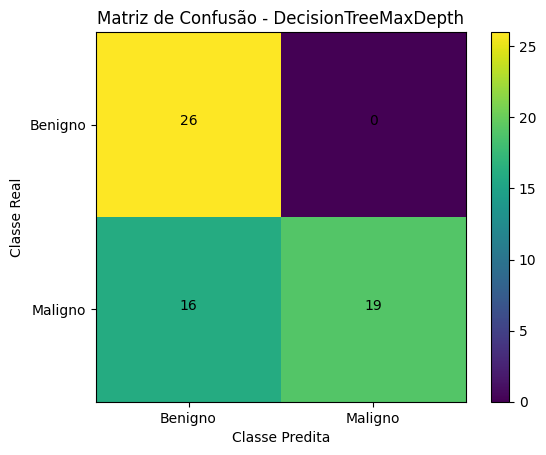

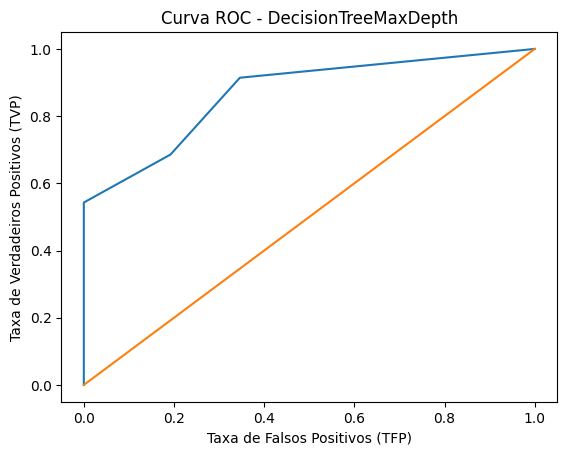

Área sob a Curva (AUC): 0.8670


[Text(0.5, 0.8333333333333334, 'x[12] <= 3.863\ngini = 0.49\nsamples = 242\nvalue = [138, 104]'),
 Text(0.25, 0.5, 'x[11] <= 0.819\ngini = 0.313\nsamples = 134\nvalue = [108, 26]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.185\nsamples = 97\nvalue = [87, 10]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.491\nsamples = 37\nvalue = [21, 16]'),
 Text(0.75, 0.5, 'x[2] <= 3.5\ngini = 0.401\nsamples = 108\nvalue = [30, 78]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.494\nsamples = 36\nvalue = [20, 16]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.239\nsamples = 72\nvalue = [10, 62]')]

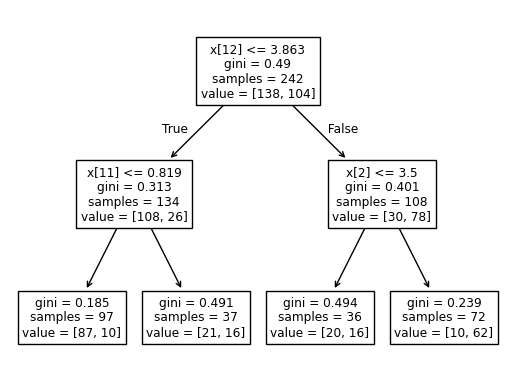

In [ ]:
# Instanciando modelo com max_depth igual a 2
dtMaxDepth = DecisionTreeClassifier(max_depth=2)
# Treinando e realizando previsões
dtMaxDepth.fit(X_train, y_train)
y_pred = dtMaxDepth.predict(X_test)
y_prob = dtMaxDepth.predict_proba(X_test)[:,1]
# Avaliando o modelo
evaluate_classifier(y_test, y_pred, y_prob, model_name="DecisionTreeMaxDepth")
# Plotando árvore
plot_tree(dtMaxDepth)

## 3) Florestas Aleatórias

Novamente, seguindo o que foi feito para Perceptrons, MLPs e Árvores de Decisão, agora o desafio é introduzir Florestas Aleatórias às comparações.

- a) Repita os 2 primeiros itens do exercício anterior, avaliando uma RandomForest no lugar da DecisionTree. Utilize os parâmetros padrão da [RandomForest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) do sklearn inicialmente. Novamente, utilize o "*X_train*" e "*X_test*" **sem pré-processamento**.
- b) Compare o desempenho do modelo RandomForest com o modelo DecisionTree e indique o melhor classificador. Note que é rasoável esperar que a RandomForest performe melhor que a Árvore de Decisão.

-------- Random Forest --------

Acurácia: 0.8525
Precisão: 0.9333
Sensibilidade (Taxa de Verdadeiros Positivos - TVP): 0.8000
Taxa de Verdadeiros Positivos (TVP): 0.8000
Taxa de Falsos Positivos (TFP): 0.0769


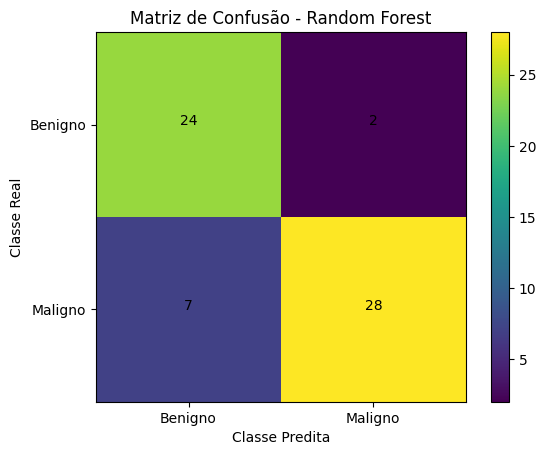

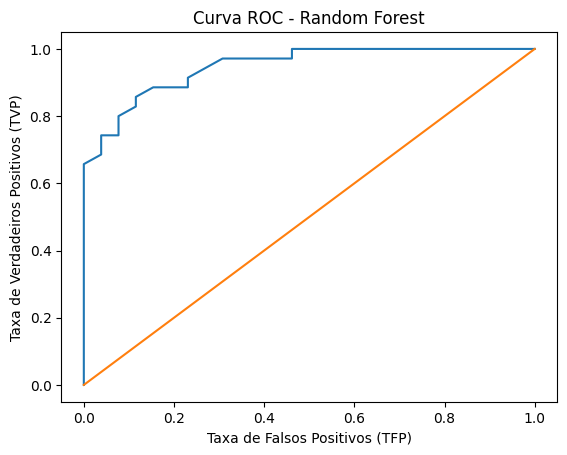

Área sob a Curva (AUC): 0.9478


In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Instanciando modelo
rf = RandomForestClassifier()
# Treinando e realizando previsões
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]
# Avaliando
evaluate_classifier(y_test, y_pred, y_prob, model_name="Random Forest")

## Questões teóricas para estudo

Não é necessário responder as perguntas a seguir para completar a atividade prática. Utilize as perguntas para estudo posteriormente.

1. Qual é a principal limitação da métrica acurácia para tarefas de classificação?
2. O que as métricas precisão e sensibilidade oferecem a mais do que a métrica acurácia?
3. Como o parâmetro "max_depth" das árvores de decisão está relacionado aos conceitos de **overfitting** e **underfitting**?
4. A que tipo de paradigma de aprendizado as árvores de decisão estão relacionadas. Justifique.
5. O método RandomForest pode ser considerado um método baseado em comitês? Justifique.
6. Por que alguns atributos costumam ter maior importância do que outros nas árvores de decisão?
7. Por que pré-processamento costuma não produzir efeito sobre a performance de métodos baseados em árvores de decisão?


1. A principal limitação da acurácia é que ela pode ser enganosa em conjuntos de dados desbalanceados. Um modelo pode apresentar alta acurácia apenas por prever majoritariamente a classe mais frequente, mesmo tendo desempenho ruim nas classes minoritárias.

2. As métricas precisão e sensibilidade (recall) oferecem uma análise mais detalhada por classe, especialmente da classe positiva, algo que a acurácia não faz.  
**Precisão:** mede quantas previsões positivas estavam corretas, avaliando a taxa de falsos positivos.  
**Sensibilidade:** mede quantos exemplos positivos reais foram corretamente identificados, avaliando a taxa de falsos negativos.  
Assim, essas métricas são mais informativas em problemas com classes desbalanceadas ou quando erros específicos possuem maior importância.

3. O parâmetro max_depth define a profundidade máxima da árvore de decisão e controla sua complexidade. Quando esse valor é muito alto, a árvore tende a crescer excessivamente, ajustando-se demais aos dados de treinamento, inclusive aos ruídos, o que pode causar overfitting e reduzir a capacidade de generalização do modelo.
Por outro lado, quando max_depth é muito baixo, a árvore pode se tornar simples demais para capturar os padrões relevantes dos dados, resultando em underfitting, ou seja, baixo desempenho tanto no treino quanto em novos dados. Portanto, esse parâmetro deve ser ajustado para equilibrar complexidade e capacidade de generalização.

4. As árvores de decisão estão relacionadas ao aprendizado supervisionado, pois o modelo é treinado a partir de um conjunto de dados rotulados, no qual as entradas possuem uma saída conhecida.

5. Sim, o método Random Forest pode ser considerado um método baseado em comitês (ensemble learning), pois ele combina múltiplas árvores de decisão para produzir uma previsão final.

6. Alguns atributos possuem maior importância nas árvores de decisão porque são mais eficazes em reduzir a impureza dos dados durante as divisões da árvore. Atributos que conseguem separar melhor as classes ou explicar melhor a variável alvo tendem a ser escolhidos nos nós superiores, influenciando mais o processo de decisão.

7. O pré-processamento costuma ter pouco efeito em métodos baseados em árvores de decisão porque esses modelos não dependem da escala dos atributos para realizar as divisões. A árvore toma decisões com base em limiares (por exemplo, x<valor), preservando a ordem dos dados independentemente de normalização ou padronização.